# Amazon Bestselling Books — Share Phase

Build the five visualizations for the publishing-client deliverable, using the small aggregate
tables produced in the Analyze phase (`data/summary/`). Palette: blue = one-hit-wonder / Fiction,
orange = repeat bestseller / Non Fiction where a two-category comparison is shown; a light-to-dark
sequential ramp for ordinal rankings.

## Setup

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import os

SUMMARY_DIR = "../data/summary"
IMG_DIR = "../images"
os.makedirs(IMG_DIR, exist_ok=True)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
RED = "#e34948"       # use for negative/diverging values only
SEQ6 = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95"]  # light->dark ordinal ramp
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "Segoe UI", "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 12,
})

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

print("Setup complete.")

Setup complete.


## 1. Most bestsellers are one-hit-wonders

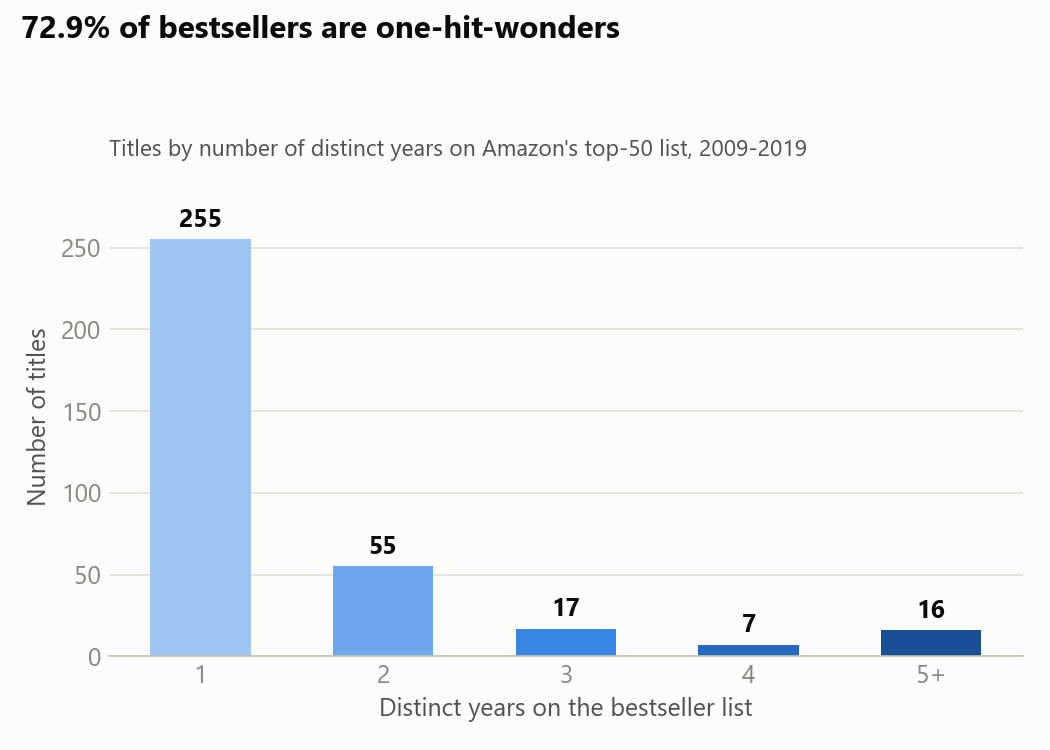

In [2]:
dist = pd.read_csv(os.path.join(SUMMARY_DIR, "times_on_list_distribution.csv"), index_col=0)
buckets = {"1": dist.loc[1, "n_titles"], "2": dist.loc[2, "n_titles"], "3": dist.loc[3, "n_titles"],
           "4": dist.loc[4, "n_titles"], "5+": dist.loc[5:, "n_titles"].sum()}
labels = list(buckets.keys())
values = list(buckets.values())

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, width=0.55, color=SEQ6[1:6])
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 4, f"{v}", ha="center", va="bottom",
             fontsize=12, color=INK_PRIMARY, fontweight="bold")
clean_axes(ax)
ax.set_xlabel("Distinct years on the bestseller list")
ax.set_ylabel("Number of titles")
ax.set_ylim(0, max(values) * 1.15)
fig.suptitle("72.9% of bestsellers are one-hit-wonders", x=0.02, ha="left", fontsize=15, fontweight="bold", y=0.98)
ax.set_title("Titles by number of distinct years on Amazon's top-50 list, 2009-2019", loc="left", fontsize=11, color=INK_SECONDARY, pad=10)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(os.path.join(IMG_DIR, "01_times_on_list_distribution.png"), dpi=150)
plt.show()

## 2. Reviews — the clearest repeat-bestseller signal

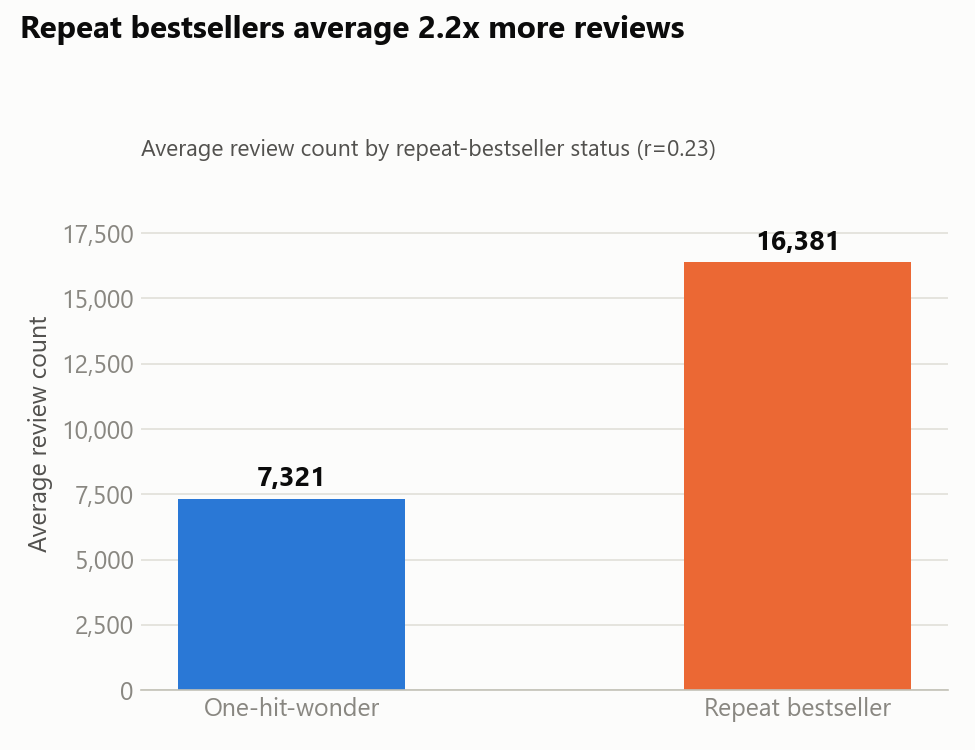

In [3]:
titles_tbl = pd.read_csv(os.path.join(SUMMARY_DIR, "titles_level_table.csv"))
is_repeat = titles_tbl["times_on_list"] > 1
cat_labels = ["One-hit-wonder", "Repeat bestseller"]
vals = [titles_tbl.loc[~is_repeat, "mean_reviews"].mean(), titles_tbl.loc[is_repeat, "mean_reviews"].mean()]

fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(cat_labels, vals, width=0.45, color=[BLUE, ORANGE])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 250, f"{v:,.0f}", ha="center", va="bottom",
             fontsize=13, color=INK_PRIMARY, fontweight="bold")
clean_axes(ax)
ax.set_ylabel("Average review count")
ax.set_ylim(0, max(vals) * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.suptitle("Repeat bestsellers average 2.2x more reviews", x=0.02, ha="left", fontsize=15, fontweight="bold", y=0.98)
ax.set_title("Average review count by repeat-bestseller status (r=0.23)", loc="left", fontsize=11, color=INK_SECONDARY, pad=10)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(os.path.join(IMG_DIR, "02_reviews_by_repeat_status.png"), dpi=150)
plt.show()

## 3. Genre barely matters

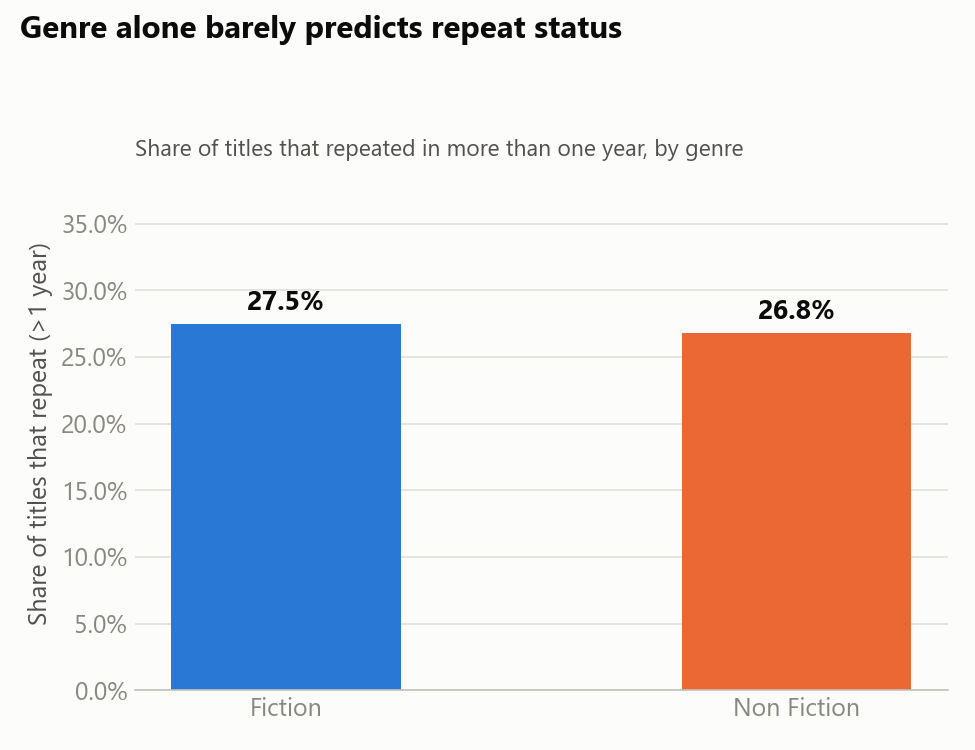

In [4]:
genre = pd.read_csv(os.path.join(SUMMARY_DIR, "genre_repeat_rate.csv")).set_index("genre")
cat_labels = ["Fiction", "Non Fiction"]
vals = [genre.loc["Fiction", "pct_repeaters"], genre.loc["Non Fiction", "pct_repeaters"]]

fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(cat_labels, vals, width=0.45, color=[BLUE, ORANGE])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.6, f"{v:.1f}%", ha="center", va="bottom",
             fontsize=13, color=INK_PRIMARY, fontweight="bold")
clean_axes(ax)
ax.set_ylabel("Share of titles that repeat (>1 year)")
ax.set_ylim(0, max(vals) * 1.4)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.suptitle("Genre alone barely predicts repeat status", x=0.02, ha="left", fontsize=15, fontweight="bold", y=0.98)
ax.set_title("Share of titles that repeated in more than one year, by genre", loc="left", fontsize=11, color=INK_SECONDARY, pad=10)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(os.path.join(IMG_DIR, "03_genre_repeat_rate.png"), dpi=150)
plt.show()

## 4. A steady price decline across the decade

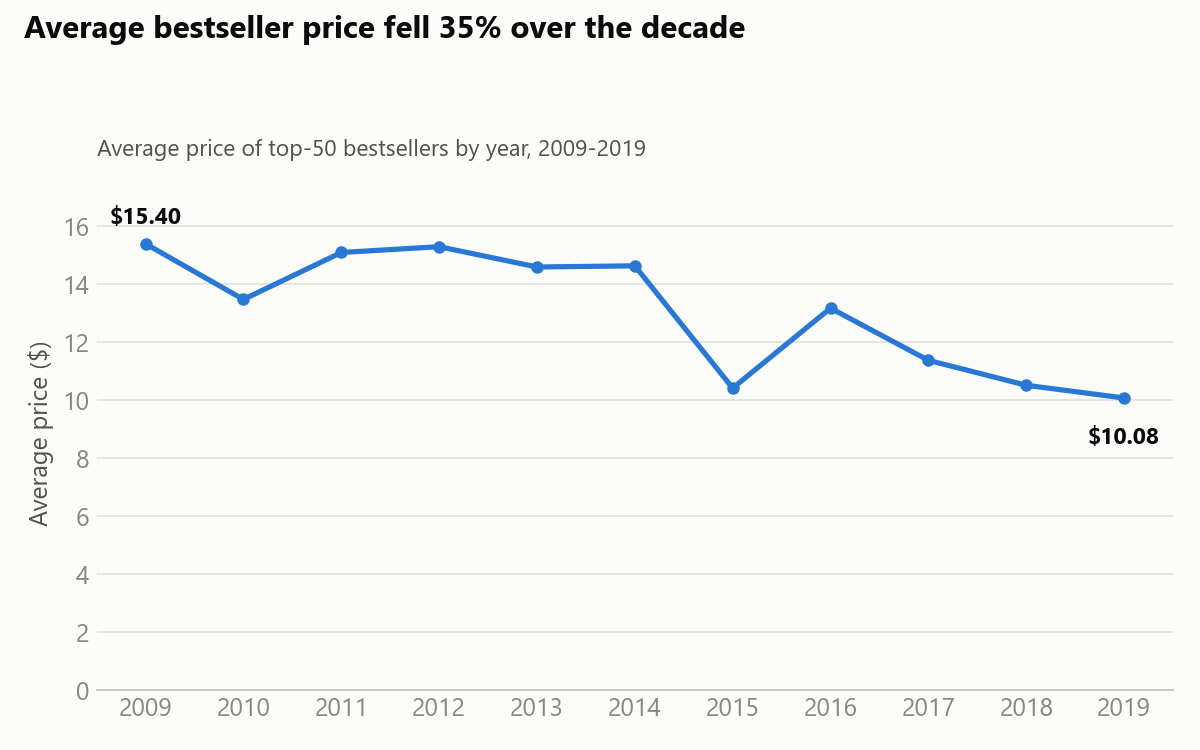

In [5]:
yt = pd.read_csv(os.path.join(SUMMARY_DIR, "year_trend.csv"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(yt["year"], yt["avg_price"], color=BLUE, linewidth=2.5, marker="o", markersize=5)
ax.text(yt["year"].iloc[0], yt["avg_price"].iloc[0] + 0.5, f"${yt['avg_price'].iloc[0]:.2f}",
        ha="center", va="bottom", fontsize=11, color=INK_PRIMARY, fontweight="bold")
ax.text(yt["year"].iloc[-1], yt["avg_price"].iloc[-1] - 1.0, f"${yt['avg_price'].iloc[-1]:.2f}",
        ha="center", va="top", fontsize=11, color=INK_PRIMARY, fontweight="bold")
clean_axes(ax)
ax.spines["bottom"].set_color(BASELINE)
ax.set_ylabel("Average price ($)")
ax.set_xticks(yt["year"])
ax.set_xticklabels(yt["year"], rotation=0)
ax.set_ylim(0, max(yt["avg_price"]) * 1.15)
fig.suptitle("Average bestseller price fell 35% over the decade", x=0.02, ha="left", fontsize=15, fontweight="bold", y=0.98)
ax.set_title("Average price of top-50 bestsellers by year, 2009-2019", loc="left", fontsize=11, color=INK_SECONDARY, pad=10)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(os.path.join(IMG_DIR, "04_price_trend.png"), dpi=150)
plt.show()

## 5. Top authors by total appearances

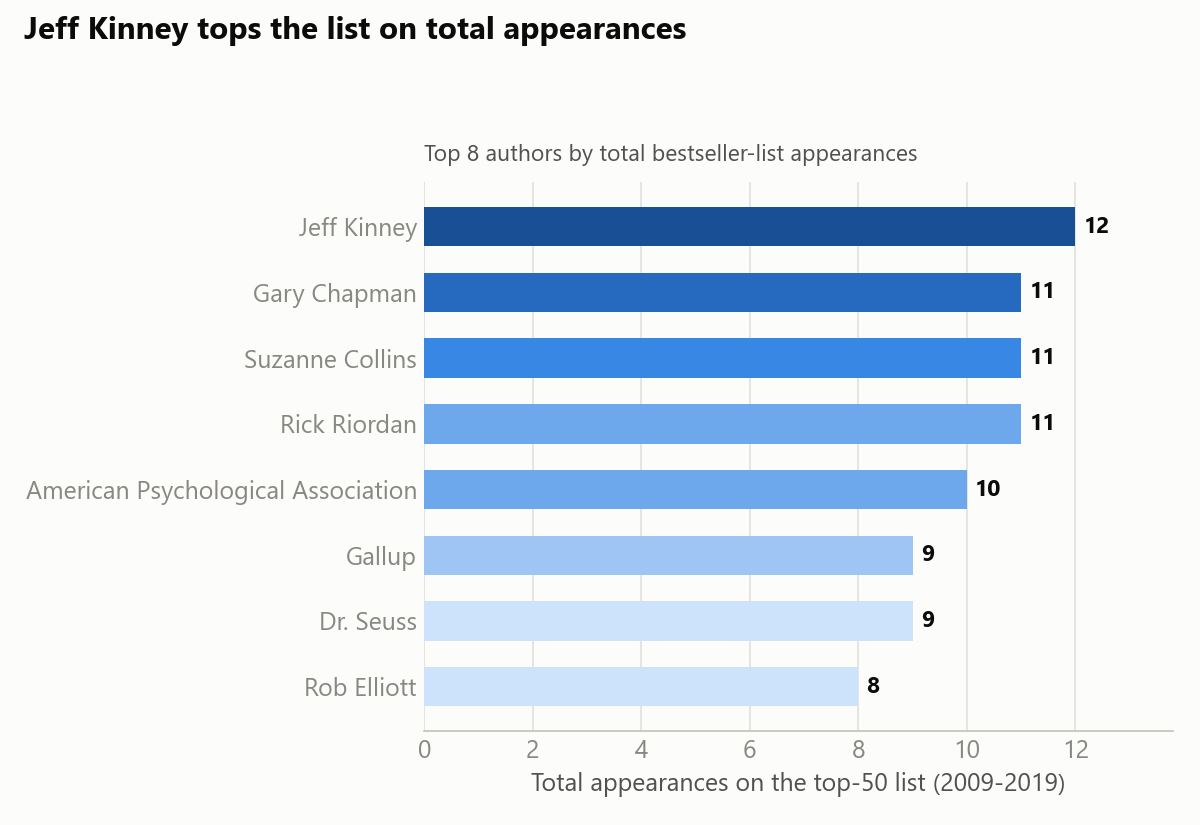

In [6]:
authors = pd.read_csv(os.path.join(SUMMARY_DIR, "top_authors.csv")).head(8)
authors = authors.sort_values("total_appearances", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
n = len(authors)
colors = [SEQ6[int(i / (n - 1) * 5)] if n > 1 else SEQ6[-1] for i in range(n)]
bars = ax.barh(authors["author"], authors["total_appearances"], height=0.6, color=colors)
for b, v in zip(bars, authors["total_appearances"]):
    ax.text(v + 0.15, b.get_y() + b.get_height()/2, f"{v}", va="center", ha="left",
             fontsize=11, color=INK_PRIMARY, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
ax.set_xlabel("Total appearances on the top-50 list (2009-2019)")
ax.set_xlim(0, authors["total_appearances"].max() * 1.15)
fig.suptitle("Jeff Kinney tops the list on total appearances", x=0.02, ha="left", fontsize=15, fontweight="bold", y=0.98)
ax.set_title("Top 8 authors by total bestseller-list appearances", loc="left", fontsize=11, color=INK_SECONDARY, pad=10)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(os.path.join(IMG_DIR, "05_top_authors.png"), dpi=150)
plt.show()

## What the data tells

Genre, price, and rating are weak predictors of repeat-bestseller status; review count is the
clearest (if still moderate) signal available in this dataset. The list skews heavily toward
one-hit-wonders, and the decade shows a steady price decline alongside rising review volume —
both largely platform-driven trends worth accounting for in any acquisition strategy built on
this data.